# 🏆 ChampIntel — UCL Match Prediction: XGBoost Training & Validation Pipeline
Dokumen eksperimen ini mencakup seluruh siklus *Machine Learning Lifecycle*:
1. **Data Loading & Preprocessing**
2. **Chronological Feature Engineering** (Anti Data-Leakage)
3. **Model Training & Hyperparameter Setup**
4. **Probability Evaluation** (Accuracy, Log Loss, Brier Score, Macro F1)
5. **SHAP Explainability**
6. **Artifacts Export** untuk integrasi FastAPI.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, log_loss, f1_score, confusion_matrix

# Setup direktori dataset dan model
RAW_DATA_PATH = os.path.join("..", "datasets", "raw", "matches.csv")
MODEL_DIR = os.path.join("..", "models")
DOCS_DIR = os.path.join("..", "..", "docs")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DOCS_DIR, exist_ok=True)

print("✅ Library berhasil dimuat dan direktori siap!")

✅ Library berhasil dimuat dan direktori siap!


In [2]:
df = pd.read_csv(RAW_DATA_PATH)
df.columns = df.columns.str.strip()

# Mapping Target: 0 = Away Win, 1 = Draw, 2 = Home Win
result_mapping = {"Away Win": 0, "Draw": 1, "Home Win": 2}
df["target"] = df["result"].map(result_mapping)
df = df.dropna(subset=["target", "home_team", "away_team", "home_goals", "away_goals"])

# Urutkan berdasarkan tanggal pertandingan untuk mencegah kebocoran waktu
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

print(f"📊 Total Pertandingan Valid: {len(df):,} laga.")
df.head(5)

📊 Total Pertandingan Valid: 25,979 laga.


,date,season,stage,home_team,away_team,score,home_goals,away_goals,result,target
0,2008-07-18,2008/2009,1,BSC Young Boys,FC Basel,1–2,1,2,Away Win,0
1,2008-07-19,2008/2009,1,FC Aarau,FC Sion,3–1,3,1,Home Win,2
2,2008-07-20,2008/2009,1,FC Luzern,FC Vaduz,1–2,1,2,Away Win,0
3,2008-07-20,2008/2009,1,Neuchâtel Xamax,FC Zürich,1–2,1,2,Away Win,0
4,2008-07-23,2008/2009,2,AC Bellinzona,Neuchâtel Xamax,1–2,1,2,Away Win,0


In [3]:
# 1. Hitung Profil Statistik Tiap Klub (untuk FastAPI)
team_stats = {}
all_teams = set(df["home_team"]).union(set(df["away_team"]))

for team in all_teams:
    home_matches = df[df["home_team"] == team]
    away_matches = df[df["away_team"] == team]
    total_matches = len(home_matches) + len(away_matches)
    if total_matches < 5:
        continue

    home_wins = len(home_matches[home_matches["result"] == "Home Win"])
    away_wins = len(away_matches[away_matches["result"] == "Away Win"])
    win_rate = (home_wins + away_wins) / total_matches

    total_scored = home_matches["home_goals"].sum() + away_matches["away_goals"].sum()
    total_conceded = home_matches["away_goals"].sum() + away_matches["home_goals"].sum()

    team_stats[team] = {
        "win_rate": round(float(win_rate), 3),
        "avg_scored": round(float(total_scored / total_matches), 2),
        "avg_conceded": round(float(total_conceded / total_matches), 2),
    }

# 2. Hitung Rolling Average Gol Secara Kronologis
team_scored, team_conceded, team_matches = {}, {}, {}
home_avg_scored, away_avg_scored = [], []
home_avg_conceded, away_avg_conceded = [], []

for idx, row in df.iterrows():
    ht, at = row["home_team"], row["away_team"]
    hg, ag = row["home_goals"], row["away_goals"]

    home_avg_scored.append(team_scored.get(ht, 1.0) / max(1, team_matches.get(ht, 1)))
    home_avg_conceded.append(team_conceded.get(ht, 1.0) / max(1, team_matches.get(ht, 1)))
    away_avg_scored.append(team_scored.get(at, 1.0) / max(1, team_matches.get(at, 1)))
    away_avg_conceded.append(team_conceded.get(at, 1.0) / max(1, team_matches.get(at, 1)))

    team_scored[ht] = team_scored.get(ht, 0.0) + hg
    team_conceded[ht] = team_conceded.get(ht, 0.0) + ag
    team_matches[ht] = team_matches.get(ht, 0) + 1

    team_scored[at] = team_scored.get(at, 0.0) + ag
    team_conceded[at] = team_conceded.get(at, 0.0) + hg
    team_matches[at] = team_matches.get(at, 0) + 1

df["home_avg_scored"] = home_avg_scored
df["home_avg_conceded"] = home_avg_conceded
df["away_avg_scored"] = away_avg_scored
df["away_avg_conceded"] = away_avg_conceded
df["match_leg"] = 1
df["elo_difference"] = 0.0

feature_columns = [
    "match_leg", "home_avg_scored", "home_avg_conceded",
    "away_avg_scored", "away_avg_conceded", "elo_difference"
]

print(f"✅ Profil {len(team_stats)} tim berhasil dibuat!")

✅ Profil 296 tim berhasil dibuat!


In [4]:
X = df[feature_columns]
y = df["target"].astype(int)

# Split Dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    max_depth=5,
    learning_rate=0.05,
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("🚀 Model XGBoost berhasil dilatih!")

🚀 Model XGBoost berhasil dilatih!


In [6]:
def multiclass_brier_score(y_true, y_prob):
    n_samples = len(y_true)
    y_true_onehot = np.zeros((n_samples, 3))
    y_true_onehot[np.arange(n_samples), y_true] = 1
    return np.mean(np.sum((y_prob - y_true_onehot) ** 2, axis=1))

preds = model.predict(X_test)
probs = model.predict_proba(X_test)

acc = accuracy_score(y_test, preds)
loss = log_loss(y_test, probs)
brier = multiclass_brier_score(y_test.values, probs)
f1 = f1_score(y_test, preds, average="macro")

print("="*40)
print(f"🎯 Akurasi (Accuracy)       : {acc * 100:.2f}%")
print(f"📉 Log Loss                 : {loss:.4f}")
print(f"📐 Multiclass Brier Score   : {brier:.4f}")
print(f"📊 Macro F1-Score           : {f1:.4f}")
print("="*40)

🎯 Akurasi (Accuracy)       : 50.83%
📉 Log Loss                 : 1.0008
📐 Multiclass Brier Score   : 0.5977
📊 Macro F1-Score           : 0.3665


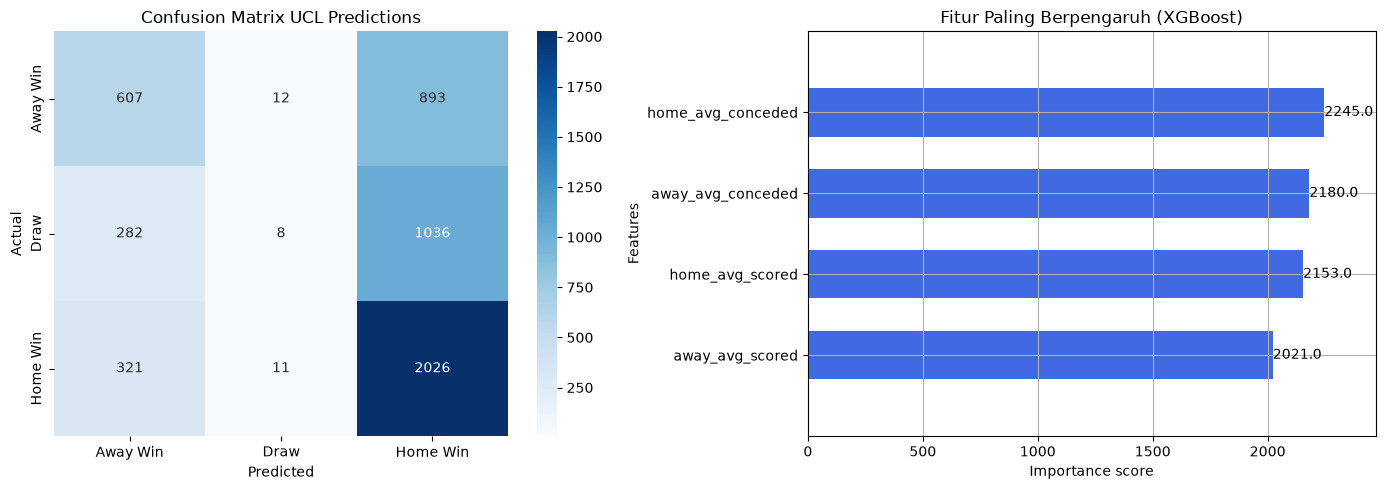

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'], ax=ax[0])
ax[0].set_title('Confusion Matrix UCL Predictions')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# 2. Feature Importance
xgb.plot_importance(model, ax=ax[1], height=0.6, color='royalblue', title='Fitur Paling Berpengaruh (XGBoost)')
plt.tight_layout()
plt.show()

In [8]:
model.save_model(os.path.join(MODEL_DIR, "xgboost_ucl.json"))

with open(os.path.join(MODEL_DIR, "feature_columns.json"), "w") as f:
    json.dump(feature_columns, f)

with open(os.path.join(MODEL_DIR, "team_stats.json"), "w") as f:
    json.dump(team_stats, f, indent=4)

print("🎉 Semua artefak model dan profil tim berhasil diekspor ke ml/models/!")

🎉 Semua artefak model dan profil tim berhasil diekspor ke ml/models/!
